In [48]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import math

import keras
from keras.models import Sequential
from keras.layers import LSTM, Flatten
from keras.layers import Dense

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error


In [49]:
data = pd.read_csv('csv_gold_price.csv')
data

,Date,Price
0,1/1/2014,29542
1,1/2/2014,29975
2,1/3/2014,29727
3,1/4/2014,29279
4,1/5/2014,29119
...,...,...
2222,2/1/2020,51260
2223,2/2/2020,51274
2224,2/3/2020,51225
2225,2/4/2020,51802


In [50]:
train_dates = pd.to_datetime(data['Date'])
train_dates

0      2014-01-01
1      2014-01-02
2      2014-01-03
3      2014-01-04
4      2014-01-05
          ...    
2222   2020-02-01
2223   2020-02-02
2224   2020-02-03
2225   2020-02-04
2226   2020-02-05
Name: Date, Length: 2227, dtype: datetime64[ns]

In [51]:
dataset = data['Price'].astype('float32')
dataset = dataset.values
dataset

array([29542., 29975., 29727., ..., 51225., 51802., 51820.], dtype=float32)

In [52]:
dataset.shape

(2227,)

In [53]:
dataset = dataset.reshape(-1, 1)
dataset.shape

(2227, 1)

In [54]:
scaler = MinMaxScaler(feature_range=(0,1))
dataset_scaled = scaler.fit_transform(dataset)
dataset_scaled

array([[0.1582731 ],
       [0.17198783],
       [0.16413277],
       ...,
       [0.8450525 ],
       [0.8633282 ],
       [0.8638983 ]], dtype=float32)

In [55]:
train_size = int(len(dataset_scaled) * 0.8)
test_size = len(dataset_scaled) - train_size
train, test = dataset_scaled[0: train_size,:],dataset_scaled[train_size:len(dataset_scaled),:] 

In [70]:
def define_prediction_window(datas, window_size):
    x = []
    y = []
    for i in range(len(datas) - window_size - 1 - 9):
        window = datas[i:(i + window_size), 0]
        x.append(window)
        y.append(datas[i + window_size + 9, 0])
        
    return np.array(x),np.array(y)

trainX, trainY = define_prediction_window(train, window_size=5)
testX, testY = define_prediction_window(test, window_size=5)

In [71]:
print('Train shape == {}'.format(trainX.shape))
print('Test shape == {}'.format(testX.shape))

Train shape == (1766, 5)
Test shape == (431, 5)


## Train

In [72]:
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

In [73]:
trainX.shape

(1766, 1, 5)

### First Try

In [74]:
model = Sequential()
model.add(LSTM(units=64, input_shape=(None,5)))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam', metrics=[keras.metrics.MeanSquaredError()])
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 64)                17920     
                                                                 
 dense_8 (Dense)             (None, 64)                4160      
                                                                 
 dense_9 (Dense)             (None, 1)                 65        
                                                                 
Total params: 22145 (86.50 KB)
Trainable params: 22145 (86.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [75]:
model.fit(trainX, trainY, validation_data=(testX, testY), verbose=2 , epochs=100)

Epoch 1/100
56/56 - 3s - loss: 0.0265 - mean_squared_error: 0.0265 - val_loss: 0.0063 - val_mean_squared_error: 0.0063 - 3s/epoch - 61ms/step
Epoch 2/100
56/56 - 0s - loss: 0.0014 - mean_squared_error: 0.0014 - val_loss: 0.0024 - val_mean_squared_error: 0.0024 - 212ms/epoch - 4ms/step
Epoch 3/100
56/56 - 0s - loss: 0.0010 - mean_squared_error: 0.0010 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 206ms/epoch - 4ms/step
Epoch 4/100
56/56 - 0s - loss: 0.0010 - mean_squared_error: 0.0010 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 213ms/epoch - 4ms/step
Epoch 5/100
56/56 - 0s - loss: 9.9277e-04 - mean_squared_error: 9.9277e-04 - val_loss: 0.0015 - val_mean_squared_error: 0.0015 - 210ms/epoch - 4ms/step
Epoch 6/100
56/56 - 0s - loss: 9.9750e-04 - mean_squared_error: 9.9750e-04 - val_loss: 0.0014 - val_mean_squared_error: 0.0014 - 208ms/epoch - 4ms/step
Epoch 7/100
56/56 - 0s - loss: 9.7403e-04 - mean_squared_error: 9.7403e-04 - val_loss: 0.0013 - val_mean_squared_error: 0.

In [76]:
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

14/14 [==============================] - 0s 2ms/step


In [77]:
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])

In [78]:
# trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:, 0]))
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:, 0]))
print('Train Score: %.2f RMSE' %(trainScore))
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:, 0]))
print('Test Score: %.2f RMSE' %(testScore))

Train Score: 889.59 RMSE
Test Score: 1082.93 RMSE


In [79]:
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:,:] = np.nan
trainPredictPlot[5:len(trainPredict) + 5, :] = trainPredict

In [87]:
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:,:] = np.nan
testPredictPlot[len(trainPredict) + (5 * 2) + 20 : len(dataset) - 1 + 30, :] = testPredict

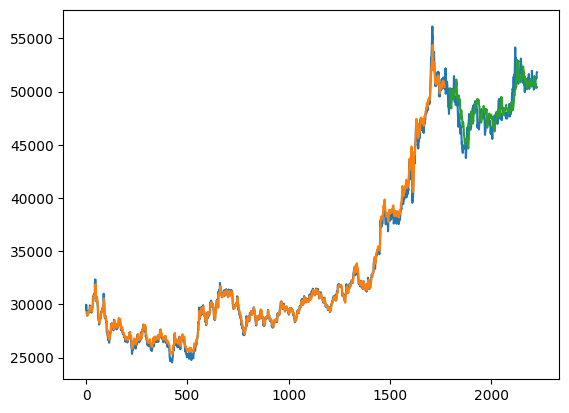

In [88]:
plt.plot(dataset)
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

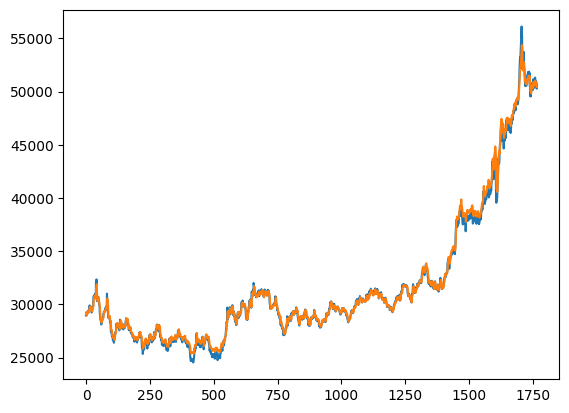

In [89]:
plt.plot(dataset[5:len(trainPredict) + 5, :])
plt.plot(trainPredict)
plt.show()

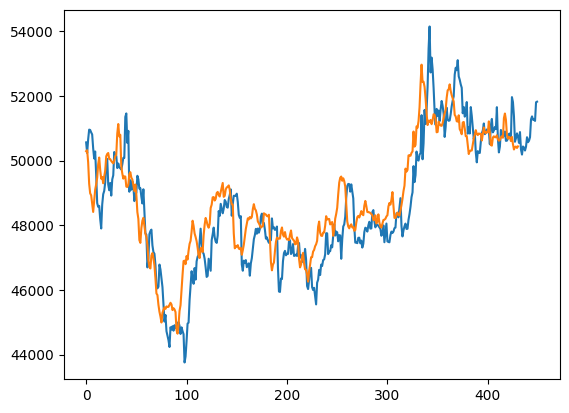

In [90]:
plt.plot(dataset[len(trainPredict) + (5 * 2) + 1 : len(dataset), :])
plt.plot(testPredict)
plt.show()

### Second Try

In [ ]:
model = Sequential()
model.add(LSTM(units=100, activation='tanh', input_shape=(None,5)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(1))
model.compile(loss='mae', optimizer='adam', metrics=[keras.metrics.MeanAbsoluteError()])
model.summary()

In [ ]:
model.fit(trainX, trainY, epochs=100, batch_size=8, verbose=2)

In [ ]:
loss, accuracy = model.evaluate(testX, testY, batch_size=8, verbose=2)